In [1]:
conda install networkx

Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


[1, 2, 3]
[(1, 2)]


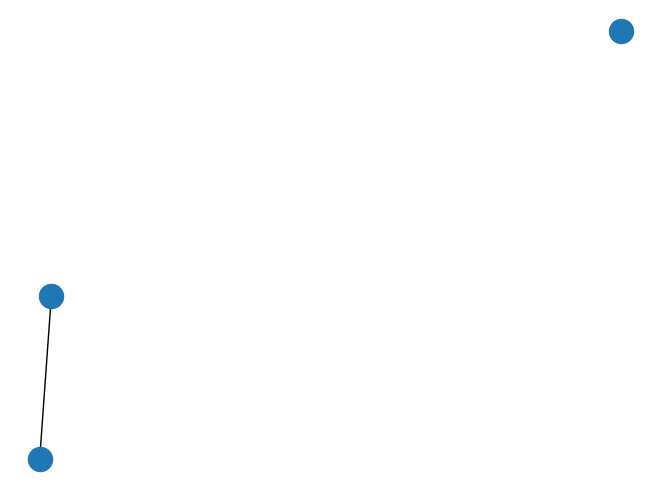

In [2]:
import networkx as nx

# Create an empty, undirected graph
G = nx.Graph()

# Add nodes and an edge
G.add_nodes_from([1, 2, 3])
G.add_edge(1, 2)

# Inspect nodes and edges
print(G.nodes())    # → [1, 2, 3]
print(G.edges())    # → [(1, 2)]

# Attach metadata
G.nodes[1]["label"] = "blue"

# Basic visualisation (requires matplotlib.pyplot as plt)
nx.draw(G)

In [3]:
!pip install osmnx

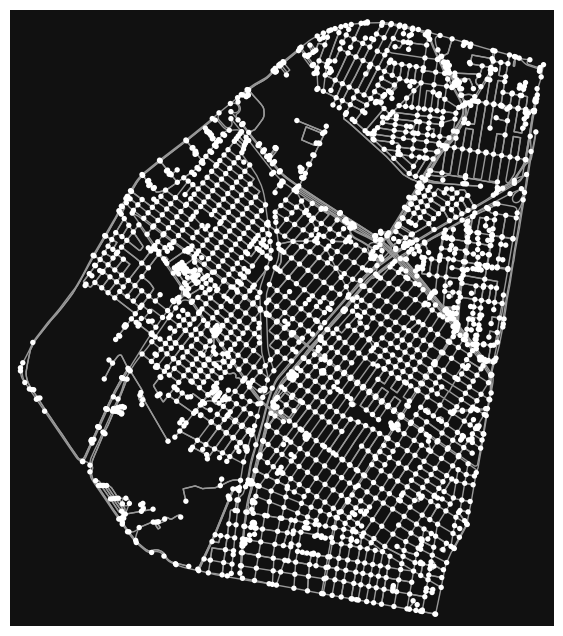

In [4]:
import osmnx

PLACE_NAME = "Barrios unidos, Bogotá, Colombia"
graph = osmnx.graph_from_place(
    PLACE_NAME,
    network_type="bike"
)
figure, ax = osmnx.plot_graph(graph)

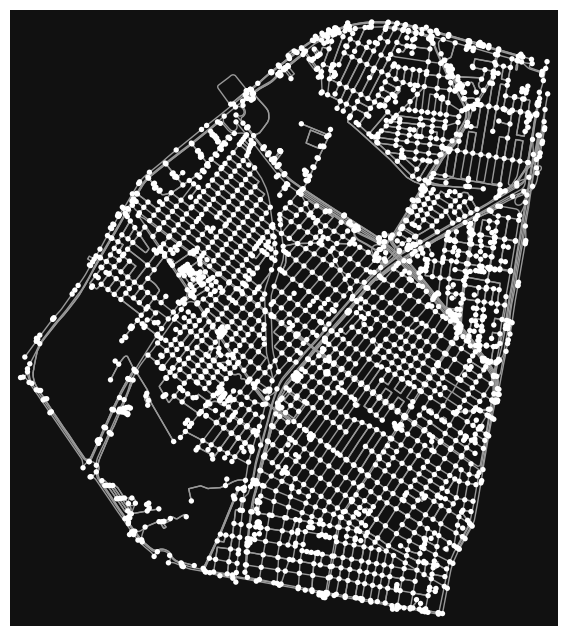

In [5]:
# Get the area of interest polygon
place_polygon = osmnx.geocode_to_gdf(PLACE_NAME)

# Re-project the polygon to a local projected CRS (so that the CRS unit is meters)
place_polygon = place_polygon.to_crs("EPSG:3067")

# Buffer by 200 meters
place_polygon["geometry"] = place_polygon.buffer(200)

# Re-project the polygon back to WGS84 (required by OSMnx)
place_polygon = place_polygon.to_crs("EPSG:4326")

# Retrieve the network graph
graph = osmnx.graph_from_polygon(
    place_polygon.at[0, "geometry"],
    network_type="bike"
)

fig, ax = osmnx.plot_graph(graph)

In [6]:
# Retrieve only edges from the graph
edges = osmnx.graph_to_gdfs(graph, nodes=False, edges=True)
edges.head()

osmid      highway lanes                name  \
u         v          key                                                     
253762065 723975752  0     45725519  residential     2           Calle 63D   
          6067062191 0    541062106        trunk     4  Avenida Carrera 30   
253762071 312656480  0     89874714  residential     2            Calle 67   
          312656101  0     89874714  residential     2            Calle 67   
          926763115  0     89875274  residential     2          Carrera 22   

                          oneway reversed      length maxspeed  \
u         v          key                                         
253762065 723975752  0     False    False    6.589048      NaN   
          6067062191 0      True    False  107.827400       60   
253762071 312656480  0     False    False   80.033867       30   
          312656101  0     False     True   68.198748       30   
          926763115  0      True    False   81.163257      NaN   

                                                                   geometry  \
u         v          key                                                      
253762065 723975752  0      LINESTRING (-74.07775 4.65561, -74.0777 4.6556)   
          6067062191 0    LINESTRING (-74.07775 4.65561, -74.07762 4.65657)   
253762071 312656480  0    LINESTRING (-74.06884 4.65751, -74.06942 4.65793)   
          312656101  0    LINESTRING (-74.06884 4.65751, -74.06832 4.65717)   
          926763115  0    LINESTRING (-74.06884 4.65751, -74.06925 4.65691)   

                         bridge junction access service width tunnel  
u         v          key                                              
253762065 723975752  0      NaN      NaN    NaN     NaN   NaN    NaN  
          6067062191 0      NaN      NaN    NaN     NaN   NaN    NaN  
253762071 312656480  0      NaN      NaN    NaN     NaN   NaN    NaN  
          312656101  0      NaN      NaN    NaN     NaN   NaN    NaN  
          926763115  0      NaN      NaN    NaN     NaN   NaN    NaN

In [7]:
edges["highway"].value_counts()

highway
residential                  3226
service                      1018
tertiary                      636
secondary                     498
cycleway                      422
primary                       202
trunk                         175
pedestrian                     70
trunk_link                     42
secondary_link                 24
primary_link                    8
[service, residential]          8
unclassified                    4
[pedestrian, residential]       4
tertiary_link                   2
track                           2
[secondary_link, primary]       1
[primary, primary_link]         1
Name: count, dtype: int64

In [8]:
# Transform the graph to UTM
graph = osmnx.project_graph(graph) 

# Extract reprojected nodes and edges
nodes, edges = osmnx.graph_to_gdfs(graph)

nodes.crs

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
# Calculate network statistics
osmnx.basic_stats(graph)

{'n': 2881,
 'm': 6343,
 'k_avg': 4.403332176327664,
 'edge_length_total': 453896.42224316543,
 'edge_length_avg': 71.55863506907858,
 'streets_per_node_avg': 3.099618188129122,
 'streets_per_node_counts': {0: 0,
  1: 374,
  2: 6,
  3: 1479,
  4: 1005,
  5: 15,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1298160360985769,
  2: 0.0020826102047900035,
  3: 0.5133634154807358,
  4: 0.3488372093023256,
  5: 0.0052065255119750084,
  6: 0.0006942034015966678},
 'intersection_count': 2507,
 'street_length_total': 322413.0732339498,
 'street_segment_count': 4387,
 'street_length_avg': 73.49283638795299,
 'circuity_avg': 1.037430971006176,
 'self_loop_proportion': 0.0013676772281741509}

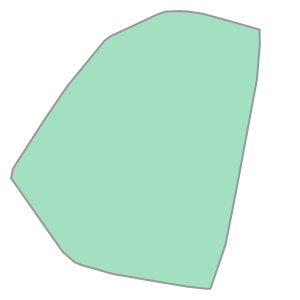

In [10]:
convex_hull = edges.geometry.union_all().convex_hull
convex_hull

In [11]:
stats = osmnx.basic_stats(graph, area=convex_hull.area)
stats

{'n': 2881,
 'm': 6343,
 'k_avg': 4.403332176327664,
 'edge_length_total': 453896.42224316543,
 'edge_length_avg': 71.55863506907858,
 'streets_per_node_avg': 3.099618188129122,
 'streets_per_node_counts': {0: 0,
  1: 374,
  2: 6,
  3: 1479,
  4: 1005,
  5: 15,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1298160360985769,
  2: 0.0020826102047900035,
  3: 0.5133634154807358,
  4: 0.3488372093023256,
  5: 0.0052065255119750084,
  6: 0.0006942034015966678},
 'intersection_count': 2507,
 'street_length_total': 322413.0732339498,
 'street_segment_count': 4387,
 'street_length_avg': 73.49283638795299,
 'circuity_avg': 1.037430971006176,
 'self_loop_proportion': 0.0013676772281741509,
 'node_density_km': 230.81835268222042,
 'intersection_density_km': 200.85442907821124,
 'edge_density_km': 36365.02064231899,
 'street_density_km': 25830.91095004248}

### 2.1. 🚀 **Now it’s your turn! — Exploring street attributes**

1. **Calculate** the total length of streets classified as `residential`, `primary`, and `secondary`.  
2. **Compare** the mean length for each class.  
3. **Visualise** the five longest street classes in a bar chart.

> 💡 *Hint:* `edges.groupby("highway")["length"].sum()` followed by `.sort_values()` will help.

In [14]:
edges["highway"] = edges["highway"].astype(str) 
selected_highways = ["residential", "primary", "secondary"]
total_length_by_type = edges[edges["highway"].isin(selected_highways)] \
    .groupby("highway")["length"].sum()
print("Longitud total por tipo de calle:")
print(total_length_by_type)

Longitud total por tipo de calle:
highway
primary         17431.589593
residential    226663.118405
secondary       38745.692251
Name: length, dtype: float64


In [16]:
mean_length_by_type = edges[edges["highway"].isin(selected_highways)] \
    .groupby("highway")["length"].mean()

print("\nLongitud media por tipo de calle:")
print(mean_length_by_type)


Longitud media por tipo de calle:
highway
primary        86.294998
residential    70.261351
secondary      77.802595
Name: length, dtype: float64


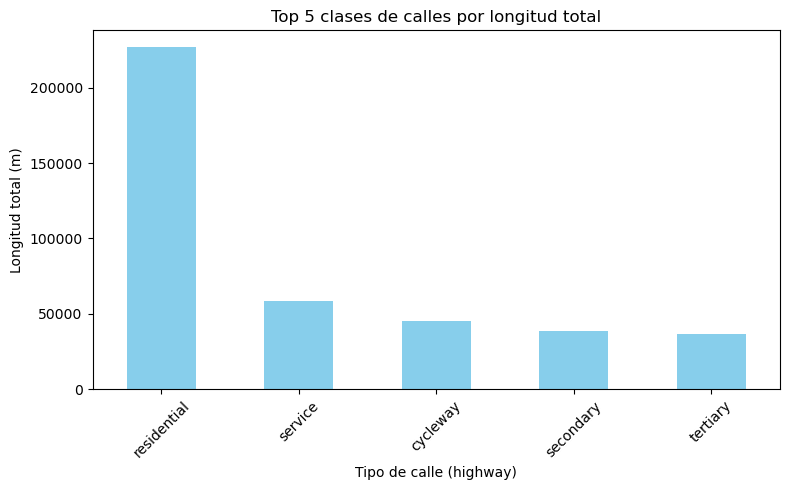

In [17]:
import matplotlib.pyplot as plt
total_length_all = edges.groupby("highway")["length"].sum().sort_values(ascending=False)
top5 = total_length_all.head(5)
top5.plot(kind="bar", figsize=(8,5), color="skyblue")
plt.title("Top 5 clases de calles por longitud total")
plt.xlabel("Tipo de calle (highway)")
plt.ylabel("Longitud total (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
!pip install myst-nb

In [13]:
import math
import myst_nb

myst_nb.glue("node_density_km", round(stats["node_density_km"], 1))
myst_nb.glue("edge_length_total", math.floor(stats["edge_length_total"] / 1000))

230.8

453

In [14]:
origin = (
    osmnx.geocode_to_gdf("parque de los novios, bogota")  # fetch geolocation
    .to_crs(edges.crs)  # transform to UTM
    .at[0, "geometry"]  # pick geometry of first row
    .centroid  # use the centre point
)

destination = (
    osmnx.geocode_to_gdf("parque la castellana, bogota")
    .to_crs(edges.crs)
    .at[0, "geometry"]
    .centroid
)

In [15]:
origin_node_id = osmnx.nearest_nodes(graph, origin.x, origin.y)
origin_node_id

6827353353

In [16]:
destination_node_id = osmnx.nearest_nodes(graph, destination.x, destination.y)
destination_node_id

9409815436

In [17]:
# Find the shortest path between origin and destination
route = osmnx.shortest_path(graph, origin_node_id, destination_node_id)
route

[6827353353,
 2374398079,
 9412674180,
 2374398041,
 267031837,
 267031833,
 722828543,
 722852549,
 722852547,
 722828499,
 267032207,
 6965090045,
 6965090047,
 3521592924,
 267032195,
 267021491,
 267021501,
 266893819,
 267021534,
 266893799,
 266893755,
 266893761,
 5750272638,
 5750272639,
 266893765,
 1052514609,
 1892456280,
 1892456296,
 1052514600,
 1833695805,
 320321930,
 1642693965,
 9546749598,
 1833695809,
 373424878,
 1052514612,
 373424838,
 373424977,
 373424918,
 373424947,
 373425038,
 373425003,
 382802775,
 1012808054,
 5115993375,
 382802770,
 373425817,
 10074986969,
 10074986963,
 382802768,
 382802758,
 316847024,
 311453417,
 12007343172,
 1367029571,
 1367029563,
 4913780072,
 505075672,
 505075650,
 505075642,
 505075639,
 505075632,
 947760898,
 505075606,
 745803389,
 885733664,
 316254516,
 867345301,
 262390999,
 6070129541,
 9374035694,
 9429162517,
 9429162519,
 316254446,
 9362584859,
 9409815436]

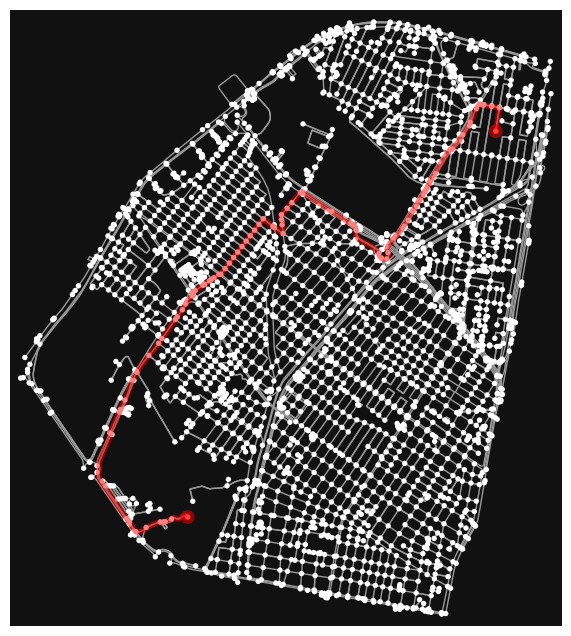

In [18]:
# Plot the shortest path
fig, ax = osmnx.plot_graph_route(graph, route)

### 3.4. 🚀 **Now it’s your turn! — Alternative routes**

1. **Calculate** a second route that avoids `motorway` and `trunk` streets.  
2. **Compare** its length with the original shortest route.  
3. **Discuss** in one sentence why constrained routes can be useful for certain users.

> 💡 You can filter `edges` before building a sub-graph or use `osmnx.utils_graph.get_route_edge_attributes`.

In [32]:
import osmnx as ox
import networkx as nx

# Función para calcular longitud de una ruta
def calcular_longitud_ruta(G, ruta):
    longitud = 0
    for u, v in zip(ruta[:-1], ruta[1:]):
        datos = G.get_edge_data(u, v)
        if datos:
            datos_arista = datos[list(datos.keys())[0]]
            longitud += datos_arista.get('length', 0)
    return longitud

# Descargar grafo de bicicletas
PLACE_NAME = "Barrios unidos, Bogotá, Colombia"
graph = ox.graph_from_place(PLACE_NAME, network_type="bike")

# Definir puntos de origen y destino usando direcciones
origin_point = ox.geocode_to_gdf("parque de los novios, bogota").at[0, "geometry"].centroid
destination_point = ox.geocode_to_gdf("parque la castellana, bogota").at[0, "geometry"].centroid

# Buscar nodos más cercanos
orig_node = ox.distance.nearest_nodes(graph, origin_point.x, origin_point.y)
dest_node = ox.distance.nearest_nodes(graph, destination_point.x, destination_point.y)

# Ruta original
ruta_original = nx.shortest_path(graph, orig_node, dest_node, weight='length')
longitud_original = calcular_longitud_ruta(graph, ruta_original)

# Crear subgrafo sin 'motorway' ni 'trunk'
nodes_all, _ = ox.graph_to_gdfs(graph)
edges_all = ox.graph_to_gdfs(graph, nodes=False, edges=True)
edges_filtradas = edges_all[~edges_all['highway'].isin(['motorway', 'trunk'])]
G_filtrado = ox.graph_from_gdfs(nodes_all, edges_filtradas)

# Ruta alternativa
ruta_alternativa = nx.shortest_path(G_filtrado, orig_node, dest_node, weight='length')
longitud_alternativa = calcular_longitud_ruta(G_filtrado, ruta_alternativa)

Ruta original: 6468.55 metros
Ruta alternativa (sin 'motorway' ni 'trunk'): 6468.55 metros


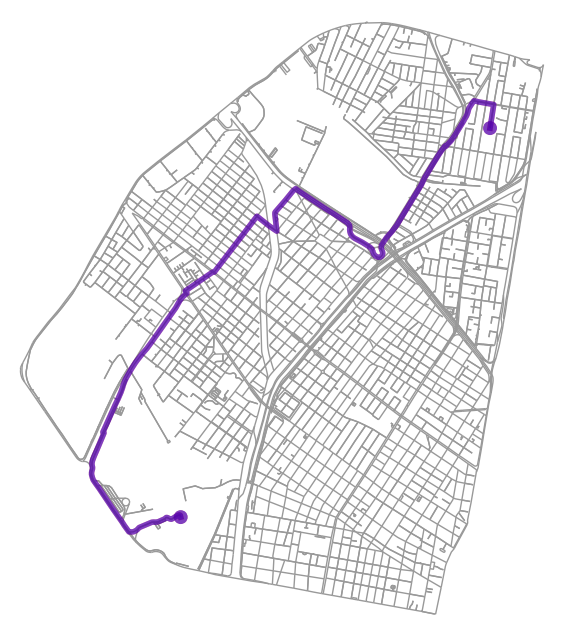

In [33]:
print(f"Ruta original: {longitud_original:.2f} metros")
print(f"Ruta alternativa (sin 'motorway' ni 'trunk'): {longitud_alternativa:.2f} metros")

# Graficar rutas
fig, ax = ox.plot_graph_routes(
    graph,
    [ruta_original, ruta_alternativa],
    route_colors=["red", "blue"],
    route_linewidth=3,
    node_size=0,
    bgcolor='white'
)


In [34]:
# Extraer atributos de la ruta original
def tipos_de_via_en_ruta(G, ruta):
    tipos = []
    for u, v in zip(ruta[:-1], ruta[1:]):
        datos = G.get_edge_data(u, v)
        if datos:
            datos_arista = datos[list(datos.keys())[0]]
            tipo = datos_arista.get('highway', 'desconocido')
            tipos.append(tipo)
    return tipos

tipos_original = tipos_de_via_en_ruta(graph, ruta_original)
tipos_filtrada = tipos_de_via_en_ruta(G_filtrado, ruta_alternativa)

print("Tipos de vía en ruta original:", set(tipos_original))
print("Tipos de vía en ruta filtrada:", set(tipos_filtrada))


Tipos de vía en ruta original: {'track', 'primary', 'cycleway', 'service', 'residential', 'secondary', 'tertiary'}
Tipos de vía en ruta filtrada: {'track', 'primary', 'cycleway', 'service', 'residential', 'secondary', 'tertiary'}


En este análisis, la comparación entre la ruta más corta y una ruta alternativa restringida para evitar vías clasificadas como motorway y trunk no mostró diferencias significativas en longitud ni trayectoria. Esto sugiere que, al trabajar con redes viales construidas con network_type="bike", OSMnx ya excluye de forma predeterminada aquellas vías no aptas para bicicletas. Por tanto, las rutas generadas respetan desde el inicio criterios de seguridad y accesibilidad, lo que puede ser especialmente útil para estudios de movilidad sostenible sin necesidad de filtros adicionales. Sin embargo, en entornos con una red vial más diversa o en análisis con network_type="all", estos filtros podrían tener un mayor impacto en los resultados.

In [19]:
# Get the nodes along the shortest path
route_nodes = nodes.loc[route]
route_nodes

,y,x,street_count,highway,geometry
osmid,,,,,
6827353353,514730.164347,601816.779143,1,NaN,POINT (601816.779 514730.164)
2374398079,514716.575927,601696.465918,3,NaN,POINT (601696.466 514716.576)
9412674180,514695.342878,601648.407727,3,NaN,POINT (601648.408 514695.343)
2374398041,514692.392772,601632.627001,3,NaN,POINT (601632.627 514692.393)
267031837,514692.795498,601610.729983,3,NaN,POINT (601610.73 514692.795)
...,...,...,...,...,...
9429162517,517833.545603,604028.775943,3,NaN,POINT (604028.776 517833.546)
9429162519,517829.520454,604044.532068,4,NaN,POINT (604044.532 517829.52)
316254446,517818.699799,604104.199721,4,traffic_signals,POINT (604104.2 517818.7)


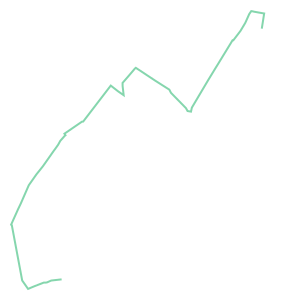

In [20]:
import shapely.geometry

# Create a geometry for the shortest path
route_line = shapely.geometry.LineString(
    list(route_nodes.geometry.values)
)
route_line

In [21]:
import geopandas

route_geom = geopandas.GeoDataFrame(
    {
        "geometry": [route_line],
        "osm_nodes": [route],
    },
    crs=edges.crs
)

# Calculate the route length
route_geom["length_m"] = route_geom.length

route_geom.head()

,geometry,osm_nodes,length_m
0,"LINESTRING (601816.779 514730.164, 601696.466 ...","[6827353353, 2374398079, 9412674180, 237439804...",6303.880866


In [22]:
buildings = osmnx.features_from_place(
    PLACE_NAME,
    {
        "building" : True
    }
).to_crs(edges.crs)

In [23]:
conda install matplotlib

Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [24]:
!pip install contextily

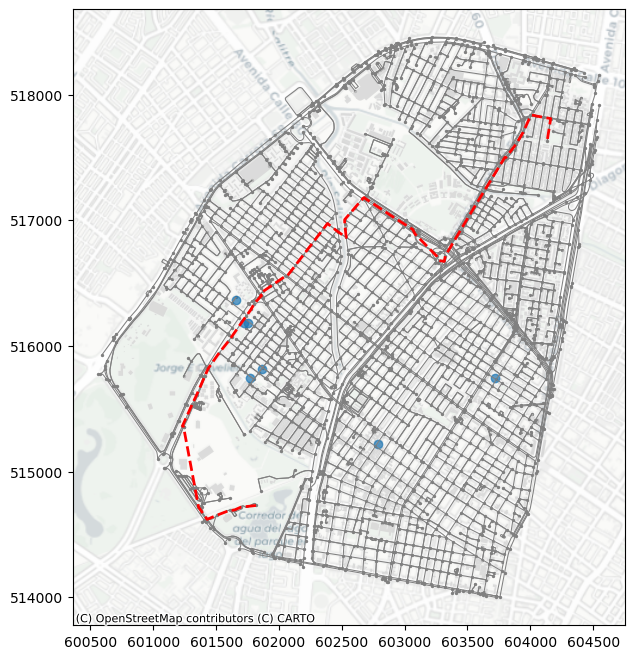

In [25]:
import contextily
import matplotlib.pyplot

fig, ax = matplotlib.pyplot.subplots(figsize=(12,8))

# Plot edges and nodes
edges.plot(ax=ax, linewidth=0.75, color='gray')
nodes.plot(ax=ax, markersize=2, color='gray')

# Add buildings
ax = buildings.plot(ax=ax, facecolor='lightgray', alpha=0.7)

# Add the route
ax = route_geom.plot(ax=ax, linewidth=2, linestyle='--', color='red')

# Add basemap
contextily.add_basemap(ax, crs=buildings.crs, source=contextily.providers.CartoDB.Positron)

In [26]:
edges.head()

osmid      highway lanes                name  \
u         v          key                                                     
253762065 723975752  0     45725519  residential     2           Calle 63D   
          6067062191 0    541062106        trunk     4  Avenida Carrera 30   
723975752 253762065  0     45725519  residential     2           Calle 63D   
          983036685  0     58293679     cycleway   NaN                 NaN   
          9235777159 0     45725519  residential     2           Calle 63D   

                          oneway reversed      length maxspeed  \
u         v          key                                         
253762065 723975752  0     False    False    6.589048      NaN   
          6067062191 0      True    False  107.827400       60   
723975752 253762065  0     False     True    6.589048      NaN   
          983036685  0     False    False   96.326218      NaN   
          9235777159 0     False    False   46.674227      NaN   

                                                                   geometry  \
u         v          key                                                      
253762065 723975752  0    LINESTRING (602290.859 514662.627, 602297.372 ...   
          6067062191 0    LINESTRING (602290.859 514662.627, 602305.562 ...   
723975752 253762065  0    LINESTRING (602297.372 514661.597, 602290.859 ...   
          983036685  0    LINESTRING (602297.372 514661.597, 602287.069 ...   
          9235777159 0    LINESTRING (602297.372 514661.597, 602301.177 ...   

                         bridge junction access service width tunnel  
u         v          key                                              
253762065 723975752  0      NaN      NaN    NaN     NaN   NaN    NaN  
          6067062191 0      NaN      NaN    NaN     NaN   NaN    NaN  
723975752 253762065  0      NaN      NaN    NaN     NaN   NaN    NaN  
          983036685  0      NaN      NaN    NaN     NaN   NaN    NaN  
          9235777159 0      NaN      NaN    NaN     NaN   NaN    NaN

In [27]:
# Columns with invalid values
problematic_columns = [
    "osmid",
    "lanes",
    "name",
    "highway",
    "width",
    "maxspeed",
    "reversed",
    "junction",
    "bridge",
    "tunnel",
    "access",
    "service",
    
]

#  convert selected columns to string format
edges[problematic_columns] = edges[problematic_columns].astype(str)

In [28]:
route_geom["osm_nodes"] = route_geom["osm_nodes"].astype(str)

In [29]:
conda install pathlib

Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [30]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"
DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)

### 🚀 **Now it’s your turn! — Extending your analysis**

1. **Create** a 50 m buffer around the route and select buildings intersecting it.  
2. **Count** buildings both in total and by `building` tag within this corridor.  
3. **Export** the result to `buildings_along_route.geojson`.  

> 💡 Try `buildings[buildings.intersects(buffer)]` or a spatial overlay with GeoPandas.


In [39]:
!pip uninstall -y osmnx
!pip install osmnx==1.3.0

Found existing installation: osmnx 2.0.4
Uninstalling osmnx-2.0.4:
  Successfully uninstalled osmnx-2.0.4


In [43]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import LineString
import requests

PLACE_NAME = "Barrios Unidos, Bogotá, Colombia"
graph = ox.graph_from_place(PLACE_NAME, network_type="bike")

origin = ox.geocode_to_gdf("parque de los novios, bogota").at[0, 'geometry'].centroid
destination = ox.geocode_to_gdf("parque la castellana, bogota").at[0, 'geometry'].centroid

orig_node = ox.distance.nearest_nodes(graph, origin.x, origin.y)
dest_node = ox.distance.nearest_nodes(graph, destination.x, destination.y)

ruta = ox.shortest_path(graph, orig_node, dest_node, weight='length')
coords = [(graph.nodes[n]['x'], graph.nodes[n]['y']) for n in ruta]
linea = LineString(coords)
ruta_gdf = gpd.GeoDataFrame(geometry=[linea], crs='EPSG:4326')

buffer = ruta_gdf.to_crs(epsg=3857).buffer(50).to_crs(epsg=4326)

minx, miny, maxx, maxy = buffer.total_bounds

query = f"""
[out:json][timeout:25];
(
  way["building"]({miny},{minx},{maxy},{maxx});
);
out geom;
"""
response = requests.get("http://overpass-api.de/api/interpreter", params={'data': query})
data = response.json()

In [45]:
from shapely.geometry import Polygon

features = []
for el in data['elements']:
    if 'geometry' in el:
        coords = [(pt['lon'], pt['lat']) for pt in el['geometry']]
        if len(coords) >= 3:
            polygon = Polygon(coords)
            if polygon.is_valid:
                features.append({
                    'geometry': polygon,
                    'building': el['tags'].get('building', 'unknown')
                })

buildings_gdf = gpd.GeoDataFrame(features, crs='EPSG:4326')

buildings_in_buffer = buildings_gdf[buildings_gdf.intersects(buffer.iloc[0])]

print(f" Total edificios en el buffer: {len(buildings_in_buffer)}")
print(" Conteo por tipo de edificio:")
print(buildings_in_buffer['building'].value_counts())

 Total edificios en el buffer: 240
 Conteo por tipo de edificio:
building
yes             226
apartments        5
roof              4
school            2
construction      2
residential       1
Name: count, dtype: int64


In [46]:
# Exportar a GeoJSON
buildings_in_buffer.to_file("buildings_along_route.geojson", driver="GeoJSON")
print("✅ Exportado como 'buildings_along_route.geojson'")

✅ Exportado como 'buildings_along_route.geojson'
